# 8.20: Lab: Experimenting with Different Functions

## Part 1
All of part 1 one has been combined into one class

In [1]:
# Imports and data import
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=13
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=13
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

I0000 00:00:1781036207.390952    5645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781036207.723085    5645 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781036209.212897    5645 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Now for the class

In [2]:
class NeuralNetBuilder:
    OPTIMIZERS = {
        'adam':     keras.optimizers.Adam,
        'sgd':      keras.optimizers.SGD,
        'rmsprop':  keras.optimizers.RMSprop,
        'adagrad':  keras.optimizers.Adagrad,
        'adamax':   keras.optimizers.Adamax,
        'nadam':    keras.optimizers.Nadam,
    }

    def __init__(
        self,
        n_inputs: int,
        hidden_units: list = [100, 100, 100],
        kernel_initializer: str = 'glorot_uniform',
        activation: str = 'relu',
        batch_norm: bool = False,
        gradient_clip_value: float = None,
        gradient_clip_norm: float = None,
        optimizer: str = 'adam',
        learning_rate: float = 1e-3,
        lr_scheduler=None,              # Part 6 — pass a Schedule object or None
    ):
        if len(hidden_units) != 3:
            raise ValueError('hidden_units must have exactly 3 values.')
        if activation not in ('relu', 'leaky_relu', 'elu', 'selu'):
            raise ValueError("activation must be one of: 'relu', 'leaky_relu', 'elu', 'selu'.")
        if gradient_clip_value is not None and gradient_clip_norm is not None:
            raise ValueError('Specify at most one of gradient_clip_value or gradient_clip_norm.')
        if optimizer not in self.OPTIMIZERS:
            raise ValueError(f"optimizer must be one of: {list(self.OPTIMIZERS.keys())}")

        self.n_inputs            = n_inputs
        self.hidden_units        = hidden_units
        self.kernel_initializer  = kernel_initializer
        self.activation          = activation
        self.batch_norm          = batch_norm
        self.gradient_clip_value = gradient_clip_value
        self.gradient_clip_norm  = gradient_clip_norm
        self.optimizer           = optimizer
        self.learning_rate       = learning_rate
        self.lr_scheduler        = lr_scheduler

        self.model = self._build()

    def _activation_layer(self):
        if self.activation == 'leaky_relu':
            return keras.layers.LeakyReLU()
        else:
            return keras.layers.Activation(self.activation)

    def _dense_block(self, units):
        layers = [
            keras.layers.Dense(
                units,
                kernel_initializer=self.kernel_initializer,
                use_bias=not self.batch_norm,
            )
        ]
        if self.batch_norm:
            layers.append(keras.layers.BatchNormalization())
        layers.append(self._activation_layer())
        return layers

    def _build(self):
        model_layers = [keras.layers.Input(shape=(self.n_inputs,))]
        for units in self.hidden_units:
            model_layers.extend(self._dense_block(units))
        model_layers.append(keras.layers.Dense(1))
        model = keras.Sequential(model_layers)

        # lr_scheduler takes priority over a plain float if provided
        lr = self.lr_scheduler if self.lr_scheduler is not None else self.learning_rate

        optimizer_kwargs = {'learning_rate': lr}
        if self.gradient_clip_value is not None:
            optimizer_kwargs['clipvalue'] = self.gradient_clip_value
        elif self.gradient_clip_norm is not None:
            optimizer_kwargs['clipnorm'] = self.gradient_clip_norm

        opt = self.OPTIMIZERS[self.optimizer](**optimizer_kwargs)

        model.compile(optimizer=opt, loss='mse', metrics=['mae'])
        return model

    def summary(self):
        print(f'\nConfig → activation={self.activation}, init={self.kernel_initializer}, '
              f'optimizer={self.optimizer}, batch_norm={self.batch_norm}, '
              f'clip_value={self.gradient_clip_value}, clip_norm={self.gradient_clip_norm}, '
              f'lr_scheduler={self.lr_scheduler}')
        self.model.summary()

    def fit(self, X_train, y_train, X_val, y_val, epochs=20, batch_size=32):
        return self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
        )

    def evaluate(self, X_test, y_test):
        mse, mae = self.model.evaluate(X_test, y_test, verbose=0)
        print(f'Test MSE: {mse:.4f}  |  Test MAE: {mae:.4f}')
        return mse, mae

### Parts b & c check

In [3]:
baseline = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='glorot_uniform',
    activation='relu',
)
baseline.summary()
baseline.fit(X_train, y_train, X_val, y_val, epochs=20)
baseline.evaluate(X_test, y_test)


Config → activation=relu, init=glorot_uniform, batch_norm=False, clip_value=None, clip_norm=None


E0000 00:00:1781019240.913281    5457 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781019240.913522    5512 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781019240.926281    5457 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6893 - mae: 0.5566 - val_loss: 0.3921 - val_mae: 0.4452
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3832 - mae: 0.4357 - val_loss: 0.3609 - val_mae: 0.4192
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3502 - mae: 0.4184 - val_loss: 0.3397 - val_mae: 0.4083
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3348 - mae: 0.4036 - val_loss: 0.3288 - val_mae: 0.4007
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3099 - mae: 0.3883 - val_loss: 0.3385 - val_mae: 0.4051
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3094 - mae: 0.3848 - val_loss: 0.3115 - val_mae: 0.3840
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2984 - mae: 0.3800 - val_loss: 0.3079 - val_mae: 0.3856
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2904 - mae: 0.3720 - val_loss: 0.3090 - val_mae: 0.3867
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

(0.29458755254745483, 0.35806334018707275)

# Checking part d

In [4]:
leaky = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='he_normal',  # recommended for ReLU-family activations
    activation='leaky_relu',
)

In [5]:
leaky.summary()
leaky.fit(X_train, y_train, X_val, y_val, epochs=20)
leaky.evaluate(X_test, y_test)


Config → activation=leaky_relu, init=he_normal, batch_norm=False, clip_value=None, clip_norm=None


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.0180 - mae: 0.6605 - val_loss: 14.0502 - val_mae: 0.5658
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13.1589 - mae: 0.6259 - val_loss: 1.0500 - val_mae: 0.5741
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6676 - mae: 0.5306 - val_loss: 1.1787 - val_mae: 0.5038
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6438 - mae: 0.5016 - val_loss: 1.0673 - val_mae: 0.5003
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.6067 - mae: 0.5591 - val_loss: 1.8471 - val_mae: 0.5399
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7059 - mae: 0.4932 - val_loss: 0.8042 - val_mae: 0.5097
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4942 - mae: 0.4657 - val_loss: 0.5258 - val_mae: 0.4972
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4319 - mae: 0.4618 - val_loss: 0.4742 - val_mae: 0.4513
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - 

(0.3995148837566376, 0.43742287158966064)

In [6]:
selu_net = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='lecun_normal',  # required for SELU's self-normalising property
    activation='selu',
    batch_norm=False,                   # BN breaks SELU's statistical assumptions
)

In [7]:
selu_net.summary()
selu_net.fit(X_train, y_train, X_val, y_val, epochs=20)
selu_net.evaluate(X_test, y_test)


Config → activation=selu, init=lecun_normal, batch_norm=False, clip_value=None, clip_norm=None


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7309 - mae: 0.5580 - val_loss: 0.7374 - val_mae: 0.5028
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5105 - mae: 0.4776 - val_loss: 0.7651 - val_mae: 0.4956
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4727 - mae: 0.4597 - val_loss: 0.4426 - val_mae: 0.4594
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4335 - mae: 0.4531 - val_loss: 0.4161 - val_mae: 0.4558
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3999 - mae: 0.4291 - val_loss: 0.3598 - val_mae: 0.4140
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3614 - mae: 0.4199 - val_loss: 0.4504 - val_mae: 0.4285
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3536 - mae: 0.4102 - val_loss: 0.3411 - val_mae: 0.4062
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3405 - mae: 0.4044 - val_loss: 0.3365 - val_mae: 0.4082
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

(0.3434355854988098, 0.42293959856033325)

### Part e - Batch Normalisation

In [8]:
bn_net = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='he_normal',
    activation='elu',
    batch_norm=True,
)

In [9]:
bn_net.summary()
bn_net.fit(X_train, y_train, X_val, y_val, epochs=20)
bn_net.evaluate(X_test, y_test)


Config → activation=elu, init=he_normal, batch_norm=True, clip_value=None, clip_norm=None


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 100)            │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100)            │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,101 (86.33 KB)

 Trainable params: 21,501 (83.99 KB)

 Non-trainable params: 600 (2.34 KB)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9059 - mae: 0.6781 - val_loss: 0.5103 - val_mae: 0.4964
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4580 - mae: 0.4939 - val_loss: 0.6763 - val_mae: 0.4871
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4282 - mae: 0.4795 - val_loss: 0.6573 - val_mae: 0.4976
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4092 - mae: 0.4669 - val_loss: 0.9423 - val_mae: 0.5252
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4034 - mae: 0.4637 - val_loss: 0.8496 - val_mae: 0.4689
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3919 - mae: 0.4554 - val_loss: 0.7405 - val_mae: 0.4893
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3762 - mae: 0.4430 - val_loss: 0.8764 - val_mae: 0.4431
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3752 - mae: 0.4421 - val_loss: 0.8667 - val_mae: 0.5015
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

(0.4899953305721283, 0.4753883183002472)

### Part f - gradient clipping

In [10]:
# Clip by norm: rescales the whole gradient vector — preserves direction, generally preferred
clip_norm = NeuralNetBuilder(n_inputs=X_train.shape[1], gradient_clip_norm=1.0)

clip_norm.summary()
clip_norm.fit(X_train, y_train, X_val, y_val, epochs=20)
clip_norm.evaluate(X_test, y_test)


Config → activation=relu, init=glorot_uniform, batch_norm=False, clip_value=None, clip_norm=1.0


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6543 - mae: 0.5523 - val_loss: 0.3749 - val_mae: 0.4324
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3770 - mae: 0.4273 - val_loss: 0.3778 - val_mae: 0.4170
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3518 - mae: 0.4081 - val_loss: 0.3581 - val_mae: 0.4151
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3179 - mae: 0.3929 - val_loss: 0.3324 - val_mae: 0.3943
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3310 - mae: 0.3851 - val_loss: 0.3281 - val_mae: 0.3870
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3057 - mae: 0.3772 - val_loss: 0.3308 - val_mae: 0.3823
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2872 - mae: 0.3711 - val_loss: 0.3163 - val_mae: 0.3918
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3232 - mae: 0.3660 - val_loss: 0.3134 - val_mae: 0.3707
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

(0.2935062050819397, 0.36980727314949036)

## Part 2 - Build randomised search

In [11]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
import pandas as pd

class NeuralNetRegressor(BaseEstimator, RegressorMixin):
    """
    Sklearn-compatible wrapper around NeuralNetBuilder.
    Inheriting BaseEstimator gives us get_params/set_params for free,
    which is what RandomizedSearchCV calls internally.
    """

    def __init__(
        self,
        hidden_units=(100, 100, 100),
        kernel_initializer='glorot_uniform',
        activation='relu',
        batch_norm=False,
        gradient_clip_value=None,
        gradient_clip_norm=None,
        learning_rate=1e-3,
        epochs=20,
        batch_size=32,
    ):
        # Argument names must exactly match attribute names for BaseEstimator
        self.hidden_units        = hidden_units
        self.kernel_initializer  = kernel_initializer
        self.activation          = activation
        self.batch_norm          = batch_norm
        self.gradient_clip_value = gradient_clip_value
        self.gradient_clip_norm  = gradient_clip_norm
        self.learning_rate       = learning_rate
        self.epochs              = epochs
        self.batch_size          = batch_size

    def fit(self, X, y):
        self.builder_ = NeuralNetBuilder(
            n_inputs=X.shape[1],
            hidden_units=list(self.hidden_units),
            kernel_initializer=self.kernel_initializer,
            activation=self.activation,
            batch_norm=self.batch_norm,
            gradient_clip_value=self.gradient_clip_value,
            gradient_clip_norm=self.gradient_clip_norm,
            learning_rate=self.learning_rate,
        )
        self.builder_.model.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=0,
        )
        return self

    def predict(self, X):
        return self.builder_.model.predict(X, verbose=0).flatten()

In [12]:
param_dist = {
    # Part c – kernel initialisers
    'kernel_initializer': ['glorot_uniform', 'glorot_normal', 'he_normal', 'he_uniform', 'lecun_normal'],

    # Part d – activation functions
    'activation': ['relu', 'leaky_relu', 'elu', 'selu'],

    # Network width – same value applied to all 3 layers for simplicity,
    # or swap for the tuple options below to vary depth/width independently
    'hidden_units': [
        (64,  64,  64),
        (100, 100, 100),
        (128, 128, 128),
        (64,  128, 64), # bottleneck
        (128, 64,  128), # hourglass
    ],

    # Part e – batch normalisation
    'batch_norm': [True, False],

    # Optimiser learning rate
    'learning_rate': uniform(loc=0.0001, scale=0.0009),  # samples from [0.0001, 0.001]

    # Part f – gradient clipping (only one active at a time; None = off)
    'gradient_clip_norm':  [None, 0.5, 1.0, 2.0],
    'gradient_clip_value': [None],  # keep off to avoid conflicting with clip_norm
}

In [13]:
# Use negative MSE because sklearn maximises scores
from sklearn.metrics import make_scorer, mean_squared_error

neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

search = RandomizedSearchCV(
    estimator=NeuralNetRegressor(),
    param_distributions=param_dist,
    n_iter=40,           # number of random configurations to try
    scoring=neg_mse_scorer,
    cv=KFold(n_splits=3, shuffle=True, random_state=13),
    n_jobs=1,            # Keras + TF don't play nicely with n_jobs > 1
    verbose=2,
    random_state=13,
    refit=True,          # refit best model on full training set at the end
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END activation=elu, batch_norm=True, gradient_clip_norm=1.0, gradient_clip_value=None, hidden_units=(64, 64, 64), kernel_initializer=he_normal, learning_rate=0.0009691742782386998; total time=   8.5s
[CV] END activation=elu, batch_norm=True, gradient_clip_norm=1.0, gradient_clip_value=None, hidden_units=(64, 64, 64), kernel_initializer=he_normal, learning_rate=0.0009691742782386998; total time=   8.1s
[CV] END activation=elu, batch_norm=True, gradient_clip_norm=1.0, gradient_clip_value=None, hidden_units=(64, 64, 64), kernel_initializer=he_normal, learning_rate=0.0009691742782386998; total time=   8.1s
[CV] END activation=relu, batch_norm=True, gradient_clip_norm=2.0, gradient_clip_value=None, hidden_units=(128, 128, 128), kernel_initializer=lecun_normal, learning_rate=0.0006466090097872456; total time=   8.5s
[CV] END activation=relu, batch_norm=True, gradient_clip_norm=2.0, gradient_clip_value=None, hidden_units=(128,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",NeuralNetRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'leaky_relu', ...], 'batch_norm': [True, False], 'gradient_clip_norm': [None, 0.5, ...], 'gradient_clip_value': [None], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [14]:
# Best configuration
print("=== Best Parameters ===")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\n  CV MSE (best): {-search.best_score_:.4f}")

# Evaluate the refit best model on the held-out test set
y_pred = search.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = np.mean(np.abs(y_test - y_pred))
print(f"\n=== Test Set Performance ===")
print(f"  MSE: {test_mse:.4f}  |  MAE: {test_mae:.4f}  |  RMSE: {np.sqrt(test_mse):.4f}")

=== Best Parameters ===
  activation: elu
  batch_norm: False
  gradient_clip_norm: 2.0
  gradient_clip_value: None
  hidden_units: (64, 128, 64)
  kernel_initializer: he_uniform
  learning_rate: 0.000701371397823176

  CV MSE (best): 0.3114

=== Test Set Performance ===
  MSE: 0.3036  |  MAE: 0.3796  |  RMSE: 0.5510


In [15]:
# Full results table, sorted by rank
results_df = pd.DataFrame(search.cv_results_)
cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_activation', 'param_kernel_initializer', 'param_hidden_units',
        'param_batch_norm', 'param_learning_rate',
        'param_gradient_clip_norm']

results_df['mean_test_score'] = -results_df['mean_test_score']  # flip sign back to MSE
results_df['std_test_score']  = results_df['std_test_score'].abs()

print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

 rank_test_score  mean_test_score  std_test_score param_activation param_kernel_initializer param_hidden_units  param_batch_norm  param_learning_rate param_gradient_clip_norm
               1         0.311366        0.005789              elu               he_uniform      (64, 128, 64)             False             0.000701                      2.0
               2         0.316192        0.015176              elu             lecun_normal    (100, 100, 100)             False             0.000882                      1.0
               3         0.325556        0.030274       leaky_relu            glorot_normal      (64, 128, 64)             False             0.000956                      2.0
               4         0.327545        0.018246              elu             lecun_normal      (64, 128, 64)             False             0.000505                      2.0
               5         0.329775        0.016514              elu             lecun_normal    (100, 100, 100)             Fa

## Part 5

In [3]:
for opt_name in ['adam', 'sgd', 'rmsprop', 'adagrad', 'nadam']:
    net = NeuralNetBuilder(
        n_inputs=X_train.shape[1],
        kernel_initializer='he_normal',
        activation='relu',
        optimizer=opt_name,
    )
    net.fit(X_train, y_train, X_val, y_val, epochs=20)
    print(f'\n{opt_name.upper()}')
    net.evaluate(X_test, y_test)

Epoch 1/20


E0000 00:00:1781036314.601940    5645 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781036314.602179    5751 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781036314.615047    5645 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1842 - mae: 0.6103 - val_loss: 2.9091 - val_mae: 0.5105
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9560 - mae: 0.4821 - val_loss: 1.3576 - val_mae: 0.4723
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.5742 - mae: 0.4481 - val_loss: 2.1321 - val_mae: 0.4931
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8345 - mae: 0.4534 - val_loss: 0.5303 - val_mae: 0.4215
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6049 - mae: 0.4239 - val_loss: 0.3412 - val_mae: 0.4093
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3818 - mae: 0.4092 - val_loss: 0.4074 - val_mae: 0.4086
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3768 - mae: 0.4055 - val_loss: 0.3514 - val_mae: 0.4045
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3225 - mae: 0.3914 - val_loss: 0.3236 - val_mae: 0.3909
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3110 

## Part 6 - Exponential Decay Scheduler
The scheduler is built separately and passed into NeuralNetBuilder via lr_scheduler. Keras schedules implement the __call__(step) interface that optimisers expect, so passing one in place of a float works transparently.

In [4]:
# Exponential decay: lr = initial_lr * decay_rate ^ (step / decay_steps)
# After each decay_steps gradient updates, the lr is multiplied by decay_rate.

initial_lr  = 1e-3
decay_steps = 1000   # roughly one full pass through the training set per epoch
decay_rate  = 0.96   # multiply lr by 0.96 every decay_steps steps

exp_decay_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_lr,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=False,  # False = smooth continuous decay; True = step-wise drops
)

In [5]:
# Baseline — fixed learning rate
fixed_lr_net = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='he_normal',
    activation='relu',
    optimizer='adam',
    learning_rate=initial_lr,
)
history_fixed = fixed_lr_net.fit(X_train, y_train, X_val, y_val, epochs=50)

# Scheduled — exponential decay
scheduled_net = NeuralNetBuilder(
    n_inputs=X_train.shape[1],
    kernel_initializer='he_normal',
    activation='relu',
    optimizer='adam',
    lr_scheduler=exp_decay_schedule,
)
history_sched = scheduled_net.fit(X_train, y_train, X_val, y_val, epochs=50)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2492 - mae: 0.6195 - val_loss: 0.4515 - val_mae: 0.4732
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4094 - mae: 0.4585 - val_loss: 0.8677 - val_mae: 0.5043
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8399 - mae: 0.4626 - val_loss: 3.2679 - val_mae: 0.4757
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8147 - mae: 0.4406 - val_loss: 0.5462 - val_mae: 0.4202
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6147 - mae: 0.4216 - val_loss: 0.5629 - val_mae: 0.4319
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4323 - mae: 0.4102 - val_loss: 0.3831 - val_mae: 0.4175
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3925 - mae: 0.4012 - val_loss: 0.3605 - val_mae: 0.4060
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3180 - mae: 0.3921 - val_loss: 0.3541 - val_mae: 0.3956
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

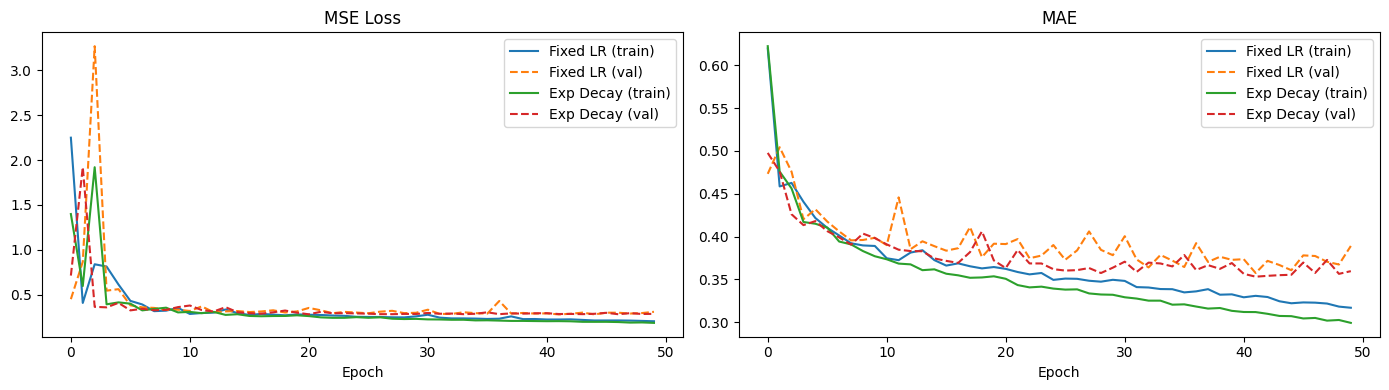


--- Fixed LR ---
Test MSE: 0.3202  |  Test MAE: 0.3927

--- Exponential Decay ---
Test MSE: 0.2898  |  Test MAE: 0.3606


(0.289815217256546, 0.3606376051902771)

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, title in zip(axes, ['loss', 'mae'], ['MSE Loss', 'MAE']):
    ax.plot(history_fixed.history[metric],        label='Fixed LR (train)')
    ax.plot(history_fixed.history[f'val_{metric}'],  label='Fixed LR (val)', linestyle='--')
    ax.plot(history_sched.history[metric],        label='Exp Decay (train)')
    ax.plot(history_sched.history[f'val_{metric}'],  label='Exp Decay (val)', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

print('\n--- Fixed LR ---')
fixed_lr_net.evaluate(X_test, y_test)
print('\n--- Exponential Decay ---')
scheduled_net.evaluate(X_test, y_test)

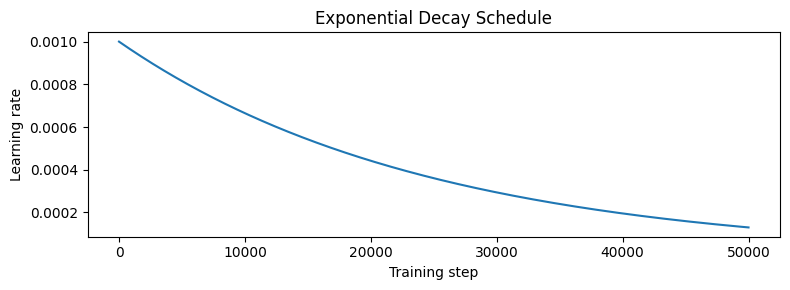

In [7]:
steps = np.arange(0, decay_steps * 50)
lrs   = [exp_decay_schedule(s).numpy() for s in steps]

plt.figure(figsize=(8, 3))
plt.plot(steps, lrs)
plt.xlabel('Training step')
plt.ylabel('Learning rate')
plt.title('Exponential Decay Schedule')
plt.tight_layout()
plt.show()